# Exploratory Data Analysis (EDA)

## 01. Univariate Analysis

### A. retail_sales

How are retail sales distributed

Why?

Understanding the distribution helps identify skewness, unusual values, and whether most products generate low or high sales.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv(r'..\data\processed\cleaned_data.csv')
df

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_12484\4025444700.py:1: DtypeWarning: Columns (0: item_code) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r'..\data\processed\cleaned_data.csv')


,year,month,supplier,item_code,item_description,item_type,retail_sales,retail_transfers,warehouse_sales
0,2026,6,20705 IMPORTS,180496,PANAS ASSYRTIKO 750ML,WINE,0.0,0.0,2.0
1,2026,6,20705 IMPORTS,574386,PARDEVALLES ALBARIN BLANCO - 750ML,WINE,0.0,0.0,1.0
2,2026,6,20705 IMPORTS,171162,PROSECCO 84 - 750ML,WINE,0.0,0.0,4.0
3,2026,6,20705 IMPORTS,171163,BENNATI CASTELLANO PINOT GRIGIO 750ML,WINE,0.0,0.0,1.0
4,2026,6,20705 IMPORTS,180495,PANAS AGIORGITIKO 750ML,WINE,0.0,0.0,2.0
...,...,...,...,...,...,...,...,...,...
318841,2017,6,Z WINE GALLERY IMPORTS LLC,345599,DOM DES PERSENADES GROS MANSENG/SAU - 750ML,WINE,0.0,0.0,1.0
318842,2017,6,Z WINE GALLERY IMPORTS LLC,232716,DOM DU VISTRE CUV GLADIATEUR ROSE - 750ML,WINE,0.0,0.0,1.0
318843,2017,6,Z WINE GALLERY IMPORTS LLC,345601,DOM DU VISTRE CUV GLADIATEUR RED - 750ML,WINE,0.0,0.0,1.0
318844,2017,6,Z WINE GALLERY IMPORTS LLC,345592,COMTE DE LANGERON BOURG P/NOIR - 750ML,WINE,0.0,0.0,1.0


In [3]:
df["retail_sales"].describe()

count    318846.000000
mean          6.969317
std          30.276781
min          -6.490000
25%           0.000000
50%           0.320000
75%           3.260000
max        1816.490000
Name: retail_sales, dtype: float64

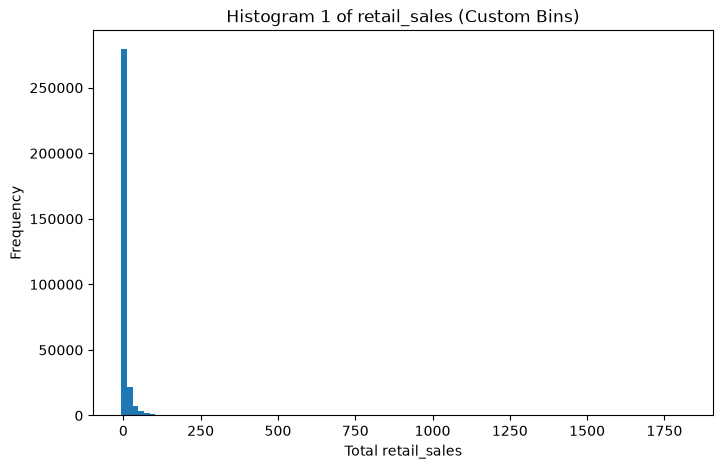

In [4]:
plt.figure(figsize=(8, 5))
plt.hist(df["retail_sales"], bins=100)
plt.title("Histogram 1 of retail_sales (Custom Bins)")
plt.xlabel("Total retail_sales")
plt.ylabel("Frequency")
plt.show()

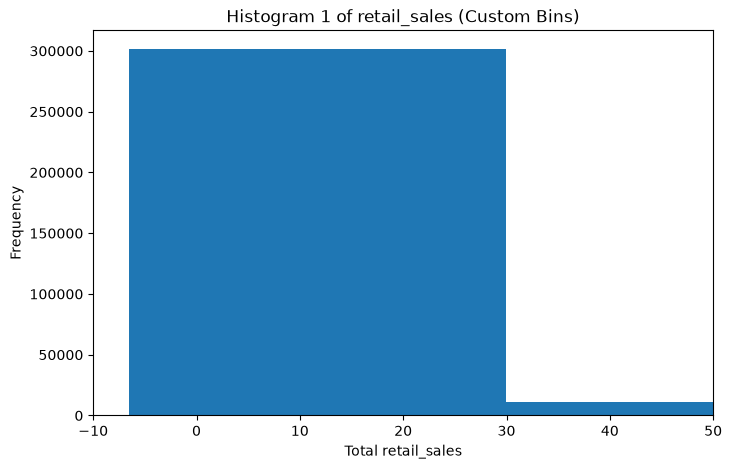

In [5]:
plt.figure(figsize=(8, 5))
plt.hist(df["retail_sales"], bins=50)
plt.xlim(-10, 50)
plt.title("Histogram 1 of retail_sales (Custom Bins)")
plt.xlabel("Total retail_sales")
plt.ylabel("Frequency")
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_12484\3589602192.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["retail_sales"], vert=False)


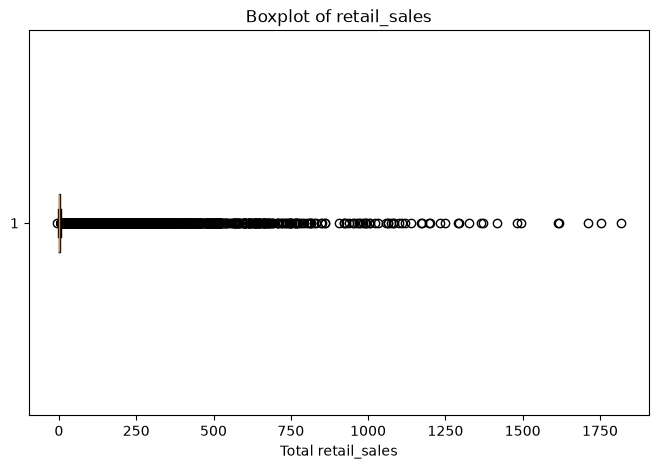

In [6]:
plt.figure(figsize=(8, 5))
plt.boxplot(df["retail_sales"], vert=False)
plt.title("Boxplot of retail_sales")
plt.xlabel("Total retail_sales")
plt.show()

my histogram showed the distibution of retail_sales is highly right skewed


histogram 1:
- most transaction are clustered very closed to 0
- There are a few transactions with very large retail_sales
- Those few huge values strecth the x-axis, makeng the majority of the data look like one tall bar

histogram 2:
- most purchases are actually small-value purchases
- Large purchases are rare
- The data is not normally distributed


A small number of products contribute disproportionately to retail sales.
This suggests that inventory planning should pay special attention to high-performing products.



---


### B. supplier
which suppliers appears most frequently?

Why?

Because maybe one supplier dominates the dataset.
If Supplier A accounts for 70% of records, that may influence the model.

In [7]:
top_supplier = df.groupby("supplier")["retail_sales"].sum().sort_values(ascending=False)
top_supplier.head(10)

supplier
E & J GALLO WINERY          172720.45
DIAGEO NORTH AMERICA INC    149491.23
CONSTELLATION BRANDS        132124.96
ANHEUSER BUSCH INC          114465.28
JIM BEAM BRANDS CO           98341.28
MILLER BREWING COMPANY       89721.79
CROWN IMPORTS                88044.32
SAZERAC CO                   75660.77
BACARDI USA INC              68807.68
THE WINE GROUP               65652.34
Name: retail_sales, dtype: float64

In [8]:
avg_supplier = df.groupby("supplier")["retail_sales"].mean().sort_values(ascending=False)
avg_supplier.head(10)

supplier
FIFTH GENERATION INC                       302.331418
FIFTH GENERATION DISTILLED SPIRITS, INC    213.673000
DOUBLE DEUCE DISTILLING LLC                111.068000
SWEET GRACE DISTILLING CO LLC               69.865238
CROWN IMPORTS                               65.363267
YUENGLING BREWERY                           49.925053
CHARLES JACQUIN ET CIE INC                  44.252941
HEINEKEN USA                                43.331212
SINGHA NORTH AMERICA INC                    30.294167
AUSTIN NICHOLS & CO                         27.125000
Name: retail_sales, dtype: float64

In [9]:
count_transaction_supplier = df.groupby("supplier")["retail_sales"].count().sort_values(ascending=False)
count_transaction_supplier.head(10)

supplier
REPUBLIC NATIONAL DISTRIBUTING CO       21005
LEGENDS LTD                             13635
SOUTHERN GLAZERS WINE AND SPIRITS       12392
E & J GALLO WINERY                      11391
THE COUNTRY VINTNER, LLC DBA WINEBOW    11237
MONSIEUR TOUTON SELECTION               10626
A VINTNERS SELECTIONS                    9994
BACCHUS IMPORTERS LTD                    9150
DIAGEO NORTH AMERICA INC                 7815
RELIABLE CHURCHILL LLLP                  7213
Name: retail_sales, dtype: int64


No single metric is sufficient to evaluate supplier performance. Total retail sales measure revenue contribution, transaction count reflects business volume, and average retail sales indicate the value generated per transaction. Combining these metrics provides a more comprehensive assessment of supplier performance and supports better business decision-making.

### C. item_code
- How many unique categories?

In [10]:
df["item_code"].nunique()

57153

### D. item_description
- How many unique categories?

In [11]:
df["item_description"].nunique()

40919

### E. item_type
- count plot
- percentage of each type

In [12]:
df["item_type"].nunique()

8

In [13]:
df["item_type"].value_counts()

item_type
WINE            193478
LIQUOR           68173
BEER             44134
KEGS             10439
NON-ALCOHOL       2134
STR_SUPPLIES       334
REF                 79
DUNNAGE             75
Name: count, dtype: int64

In [14]:
df["item_type"].value_counts(normalize=True) * 100

item_type
WINE            60.680705
LIQUOR          21.381168
BEER            13.841792
KEGS             3.273994
NON-ALCOHOL      0.669289
STR_SUPPLIES     0.104753
REF              0.024777
DUNNAGE          0.023522
Name: proportion, dtype: float64

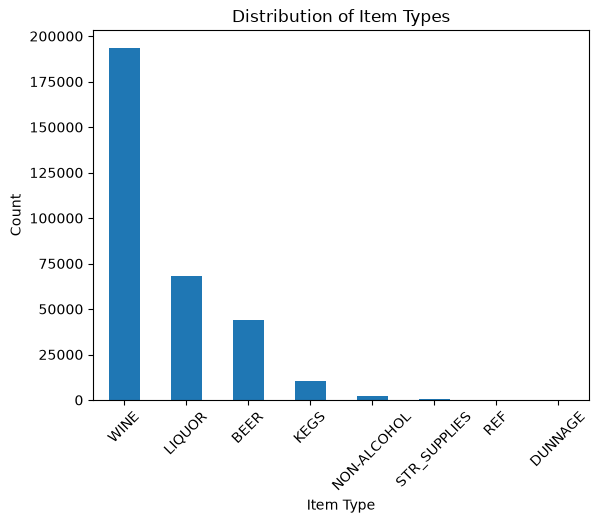

In [15]:
df["item_type"].value_counts().plot(kind="bar")

plt.title("Distribution of Item Types")
plt.xlabel("Item Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

The dataset is dominated by wine products, followed by liquor and beer.This indicates that wine accounts for the largest share of recorded transactions, suggesting that analyses and predictive models may be influenced more heavily by wine-related sales.

### F. retail_transfers

In [16]:
df["retail_transfers"].describe()

count    318846.000000
mean          6.948861
std          30.338694
min         -38.490000
25%           0.000000
50%           0.000000
75%           3.000000
max        1990.830000
Name: retail_transfers, dtype: float64

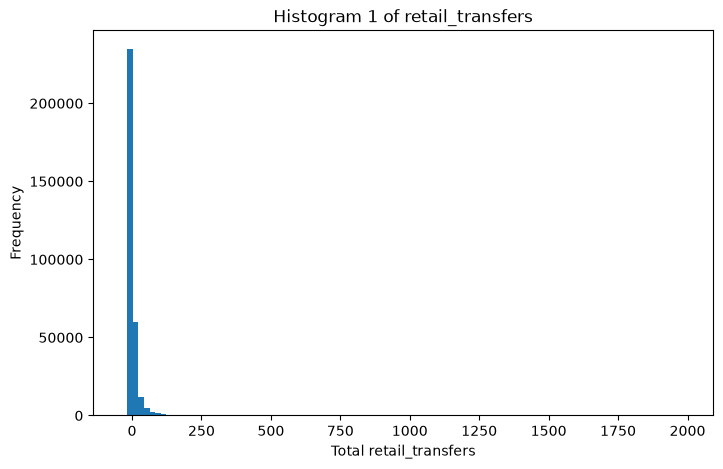

In [17]:
plt.figure(figsize=(8, 5))
plt.hist(df["retail_transfers"], bins=100)
plt.title("Histogram 1 of retail_transfers")
plt.xlabel("Total retail_transfers")
plt.ylabel("Frequency")
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_12484\3374742010.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["retail_transfers"], vert=False)


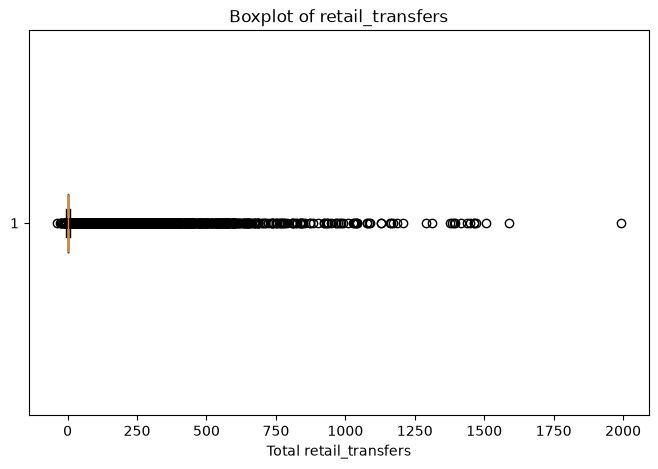

In [18]:
plt.figure(figsize=(8, 5))
plt.boxplot(df["retail_transfers"], vert=False)
plt.title("Boxplot of retail_transfers")
plt.xlabel("Total retail_transfers")
plt.show()

The distribution of retail_transfers is highly right-skewed, similiar to retail_sales. Most transfer transactions involve relatively small quantities, while a small number of transfers are substantially larger. This suggest that inventory movements, like customer sales, are dominated by many small transactions and a few high-volume events.

### G. warehouse_sales

In [19]:
df["warehouse_sales"].describe()

count    318846.000000
mean         25.539654
std         250.204116
min       -4996.000000
25%           0.000000
50%           1.000000
75%           5.000000
max       18317.000000
Name: warehouse_sales, dtype: float64

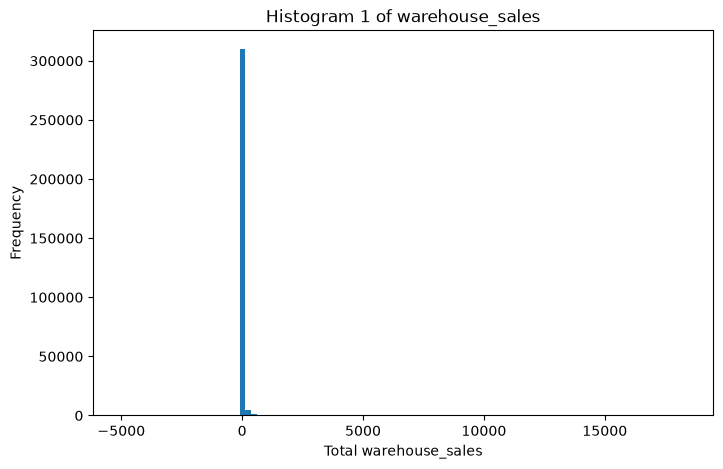

In [20]:
plt.figure(figsize=(8, 5))
plt.hist(df["warehouse_sales"], bins=100)
plt.title("Histogram 1 of warehouse_sales")
plt.xlabel("Total warehouse_sales")
plt.ylabel("Frequency")
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_12484\476243774.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["warehouse_sales"], vert=False)


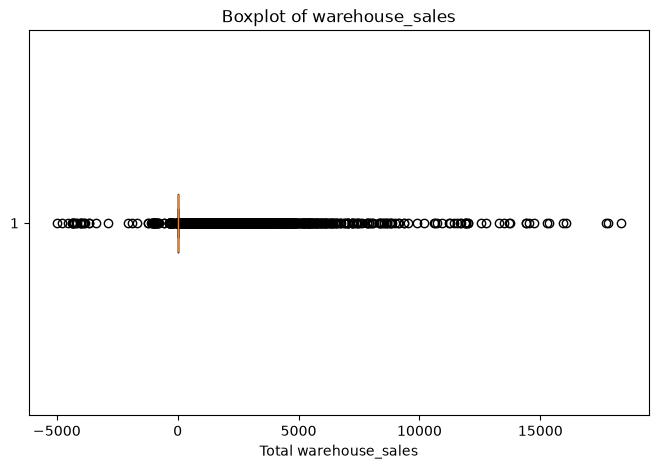

In [21]:
plt.figure(figsize=(8, 5))
plt.boxplot(df["warehouse_sales"], vert=False)
plt.title("Boxplot of warehouse_sales")
plt.xlabel("Total warehouse_sales")
plt.show()

The warehouse_sales variable exhibits a highly right-skewed distribution. While the average warehouse sale is 25.54 units, the median is only 1 unit, indicating that a small number of extremely large transactions substantially increase the mean. Furthermore, 75% of transactions involve five units or fewer, whereas the maximum reaches 18,317 units. Negative values are also present, likely representing inventory returns or stock adjustments rather than data entry errors.

## Univariate Analysis Summary

key findings:
- Retail sales distribution with right-skewed distibution with numerous high-value outliers
- Retail transfers & warehouse sales show a similiar right-skewed pattern, indicating that most transaction are small while a few are exceptionally large
- The dataset contain negative values in retail sales, retail transfers, and warehouse sales, which may represent returns or inventory adnustments.
- Wine is the dominant product type in the dataset

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 318846 entries, 0 to 318845
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   year              318846 non-null  int64  
 1   month             318846 non-null  int64  
 2   supplier          318846 non-null  str    
 3   item_code         318846 non-null  object 
 4   item_description  318846 non-null  str    
 5   item_type         318846 non-null  str    
 6   retail_sales      318846 non-null  float64
 7   retail_transfers  318846 non-null  float64
 8   warehouse_sales   318846 non-null  float64
dtypes: float64(3), int64(2), object(1), str(3)
memory usage: 21.9+ MB


## 02. Bivariate Analysis
### Target vs Numerical Features

In [23]:
numeric_columns = [
    "warehouse_sales",
    "retail_transfers",
    "retail_sales"
]

In [24]:
corr = df[numeric_columns].corr()
corr

,warehouse_sales,retail_transfers,retail_sales
warehouse_sales,1.000000,0.493935,0.499687
retail_transfers,0.493935,1.000000,0.978446
retail_sales,0.499687,0.978446,1.000000


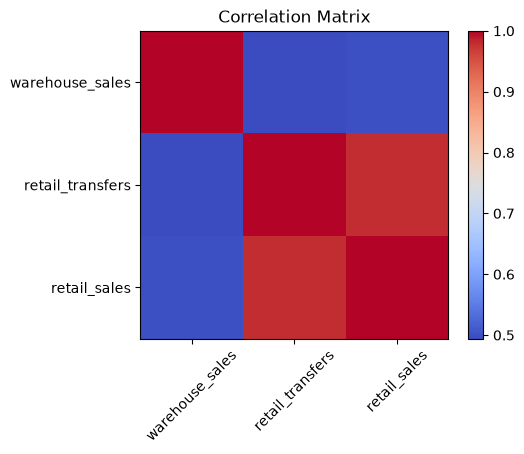

In [25]:
plt.figure(figsize=(5, 4))
plt.imshow(corr, cmap="coolwarm", interpolation="nearest")
plt.colorbar()
plt.title("Correlation Matrix")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.show()

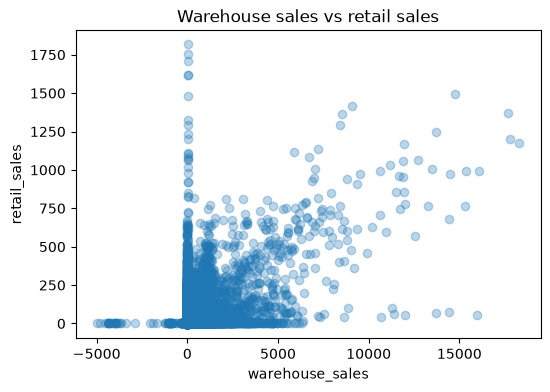

In [26]:
plt.figure(figsize=(6, 4))
plt.scatter(df["warehouse_sales"], df["retail_sales"], alpha=0.3)
plt.title("Warehouse sales vs retail sales")
plt.xlabel("warehouse_sales")
plt.ylabel("retail_sales")
plt.show()

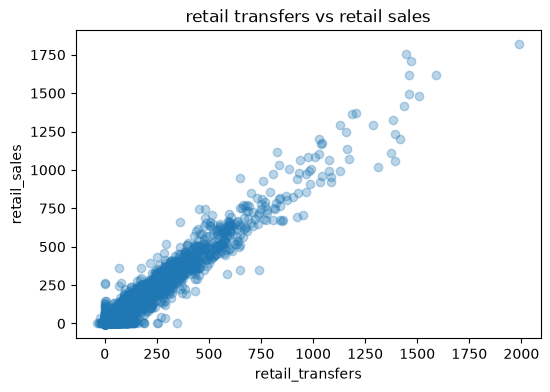

In [27]:
plt.figure(figsize=(6, 4))
plt.scatter(df["retail_transfers"], df["retail_sales"], alpha=0.3)
plt.title("retail transfers vs retail sales")
plt.xlabel("retail_transfers")
plt.ylabel("retail_sales")
plt.show()

Insight
- Retail transfers show a very strong positive correlation with retail sales (r=0.978)
- The scatter plot indicates an almost linear relationship
- This suggests retail transfers could be an important predictor for the regression model
- However, correlation alone does not prove a causal relationship, so further analysis is needed

### Target vs Categorical feature

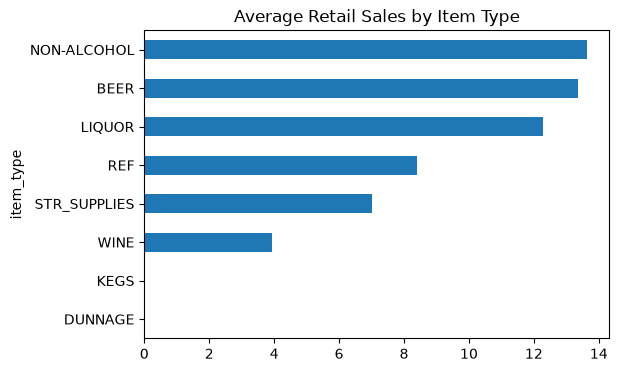

In [28]:
avg_sales = df.groupby("item_type")["retail_sales"].mean().sort_values()

avg_sales.plot(kind="barh", figsize=(6, 4))
plt.title("Average Retail Sales by Item Type")
plt.show()

In [31]:
df["year"].unique()

array([2026, 2020, 2019, 2018, 2017])

In [32]:
df["year"].value_counts().sort_index()

year
2017     96262
2018     26439
2019    138542
2020     46234
2026     11369
Name: count, dtype: int64

In [33]:
df.groupby("year")["retail_sales"].agg(["count", "sum"])

,count,sum
year,,
2017,96262,686734.57
2018,26439,153595.90
2019,138542,958179.83
2020,46234,354949.09
2026,11369,68679.53


In [34]:
df.groupby("year")["month"].unique().sort_index()

year
2017               [12, 11, 10, 9, 8, 7, 6]
2018                                 [2, 1]
2019    [11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1]
2020                           [9, 7, 3, 1]
2026                                    [6]
Name: month, dtype: object

In [38]:
df.groupby("year")["retail_sales"].describe()

,count,mean,std,min,25%,50%,75%,max
year,,,,,,,,
2017,96262.0,7.134015,31.182695,-6.49,0.0,0.40,3.820,1616.60
2018,26439.0,5.809444,23.776980,-0.58,0.0,0.40,3.005,983.02
2019,138542.0,6.916169,30.634707,-1.17,0.0,0.24,2.880,1752.45
2020,46234.0,7.677231,31.297657,-0.42,0.0,0.17,3.730,1816.49
2026,11369.0,6.040947,27.110926,-0.58,0.0,0.17,3.280,1327.43


In [39]:
df[df["year"] == 2026]["supplier"].value_counts()

supplier
SOUTHERN GLAZERS WINE AND SPIRITS       672
E & J GALLO WINERY                      575
THE COUNTRY VINTNER, LLC DBA WINEBOW    568
REYES HOLDINGS LLC                      549
PRESTIGE BEVERAGE GROUP OF MD LLC       436
                                       ... 
TEP CONSULTING LLC                        1
USA WINE IMPORTS                          1
VINTURE WINE COMPANY LLC                  1
WEIN-BAUER INC                            1
WHEELER BEVERAGE GROUP, LLC               1
Name: count, Length: 322, dtype: int64

In [42]:
df[df["year"] == 2026]["item_type"].value_counts()

item_type
WINE            5838
LIQUOR          3263
BEER            1721
KEGS             293
NON-ALCOHOL      235
STR_SUPPLIES      16
DUNNAGE            3
Name: count, dtype: int64

In [40]:
df["date"] = pd.to_datetime(
    dict(year=df["year"], month=df["month"], day=1)
)

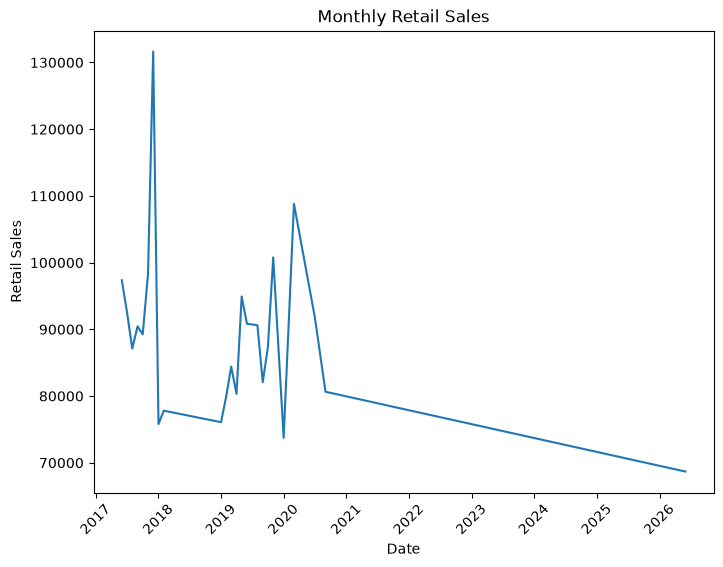

In [41]:
monthly_sales = df.groupby("date")["retail_sales"].sum()

plt.figure(figsize=(8, 6))
plt.plot(monthly_sales.index, monthly_sales.values)
plt.title("Monthly Retail Sales")
plt.xlabel("Date")
plt.ylabel("Retail Sales")
plt.xticks(rotation=45)
plt.show()

In [36]:
supplier = df.groupby("supplier")["retail_sales"].sum().sort_values(ascending=False).to_frame()
top_supplier = supplier.head(10)
top_supplier

,retail_sales
supplier,
E & J GALLO WINERY,172720.45
DIAGEO NORTH AMERICA INC,149491.23
CONSTELLATION BRANDS,132124.96
ANHEUSER BUSCH INC,114465.28
JIM BEAM BRANDS CO,98341.28
MILLER BREWING COMPANY,89721.79
CROWN IMPORTS,88044.32
SAZERAC CO,75660.77
BACARDI USA INC,68807.68


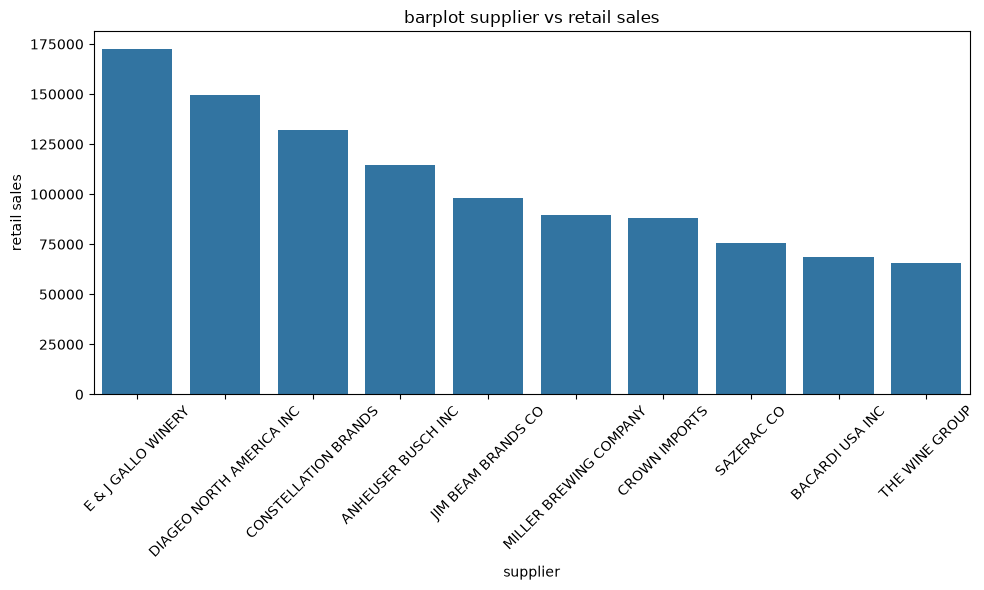

In [37]:
plt.figure(figsize=(10, 6))
sns.barplot(data=top_supplier, x="supplier", y="retail_sales")
plt.title("barplot supplier vs retail sales")
plt.xlabel("supplier")
plt.xticks(rotation=45)
plt.ylabel("retail sales")
plt.tight_layout()
plt.show()

## Bivariate Analysis Summary

- Retail transfers show a very strong positive correlation with retail sales (r=0.978)
- The scatter plot indicates an almost linear relationship
- This suggests retail transfers could be an important predictor for the regression model
- Non-alcohol type item is the most average retail_sales followed by beer and liquor
- The dataset contains an unexpected jump from 2022 to 2026.This indicate a data quality issue, so the 2026 records should be investigated before performing time series analysis
- The dataset contains records from 2026, while the majority of observations are between 2017 and 2020. Since only June appears in 2026, these records may represent newly collected data or a data entry issue. Further investigation is required before using this variable for time series forecasting. 
- Top 10 Supplier: 
1. E & J GALLO WINERY	        172720.45
2. DIAGEO NORTH AMERICA INC	    149491.23
3. CONSTELLATION BRANDS	        132124.96
4. ANHEUSER BUSCH INC	        114465.28
5. JIM BEAM BRANDS CO	        98341.28
6. MILLER BREWING COMPANY	    89721.79
7. CROWN IMPORTS	            88044.32
8. SAZERAC CO	                75660.77
9. BACARDI USA INC	            68807.68
10. THE WINE GROUP	            65652.34